# Cell 1: Installations 

In [1]:
!pip install tensorflow==2.13.0
!pip install scikit-plot
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.2/524.2 MB 3.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 90.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 94.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.8/440.8 kB 22.6 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing_extensions-4.15.0
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstall

# Cell 2: Import everything

In [2]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121, EfficientNetB0, ResNet50
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from scipy import stats  # For statistical tests

import os
import time
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.13.0


# Cell 2.5: Add ROC curve function

In [3]:

def plot_multiclass_roc_curve(y_true, y_pred_proba, class_names, model_name):
    """Plot ROC curve for multiclass classification"""
    n_classes = len(class_names)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true == i, y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(np.eye(n_classes)[y_true].ravel(), y_pred_proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    
    # Micro-average ROC curve
    plt.plot(fpr["micro"], tpr["micro"],
             label='Micro-average ROC (AUC = {0:0.2f})'.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)
    
    # Individual class ROC curves
    colors = plt.cm.rainbow(np.linspace(0, 1, n_classes))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='{0} (AUC = {1:0.2f})'.format(class_names[i], roc_auc[i]))
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - {model_name}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return roc_auc

print("ROC curve function added successfully!")

ROC curve function added successfully!


# Cell 3: Dataset configuration

In [4]:

dataset_path = "/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh/Raw-Images"

# Plant mapping from Task 1
plant_mapping = {
    'type_1': 'Kalochitra',
    'type_2': 'Anantamu', 
    'type_3': 'Apang',
    'type_4': 'Syspan',
    'type_5': 'Appishikha',
    'type_6': 'Kalamegh',
    'type_7': 'Kalothutura',
    'type_8': 'Gshnru',
    'type_9': 'Chapalish',
    'type_10': 'Beta',
    'type_11': 'Punarnava',
    'type_12': 'Bamonhati',
    'type_13': 'Basok',
    'type_14': 'Ramtulsi',
    'type_15': 'Shotomuli',
    'type_16': 'Sarpagandha'
}

# Training parameters (MUST BE CONSISTENT ACROSS ALL MODELS)
IMG_SIZE = (224, 224)  # Standard size for pre-trained models
BATCH_SIZE = 32
EPOCHS = 100
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.15
RANDOM_SEED = 42  # Instruction 1 - Fixed seed for reproducibility

print("Dataset Configuration:")
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Validation Split: {VALIDATION_SPLIT}")
print(f"Test Split: {TEST_SPLIT}")
print(f"Random Seed: {RANDOM_SEED}")

Dataset Configuration:
Image Size: (224, 224)
Batch Size: 32
Epochs: 100
Validation Split: 0.2
Test Split: 0.15
Random Seed: 42


# Cell 4: Data loading function

In [5]:

def load_and_prepare_data():
    """
    Load images and labels from the dataset
    Returns: images, labels, and class names
    """
    images = []
    labels = []
    class_names = []
    
    print("Loading dataset:")
    
    for type_folder, plant_name in plant_mapping.items():
        folder_path = os.path.join(dataset_path, type_folder)
        
        if os.path.exists(folder_path):
            image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            for img_file in image_files:
                img_path = os.path.join(folder_path, img_file)
                try:
                    # Instruction 2 - Data transfer/resize part (separate from normalization)
                    img = Image.open(img_path).convert('RGB')
                    img = img.resize(IMG_SIZE)
                    img_array = np.array(img)
                    
                    images.append(img_array)
                    labels.append(list(plant_mapping.keys()).index(type_folder))
                    
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
                    continue
            
            class_names.append(plant_name)
            print(f"Loaded {len(image_files)} images from {plant_name} ({type_folder})")
    
    images = np.array(images)
    labels = np.array(labels)
    
    print(f"\nDataset Summary:")
    print(f"Total images: {len(images)}")
    print(f"Total labels: {len(labels)}")
    print(f"Number of classes: {len(class_names)}")
    print(f"Image shape: {images[0].shape}")
    
    return images, labels, class_names

# Load the data
images, labels, class_names = load_and_prepare_data()

Loading dataset:
Loaded 201 images from Kalochitra (type_1)
Loaded 158 images from Anantamu (type_2)
Loaded 280 images from Apang (type_3)
Loaded 294 images from Syspan (type_4)
Loaded 138 images from Appishikha (type_5)
Loaded 294 images from Kalamegh (type_6)
Loaded 276 images from Kalothutura (type_7)
Loaded 238 images from Gshnru (type_8)
Loaded 238 images from Chapalish (type_9)
Loaded 194 images from Beta (type_10)
Loaded 407 images from Punarnava (type_11)
Loaded 134 images from Bamonhati (type_12)
Loaded 151 images from Basok (type_13)
Loaded 154 images from Ramtulsi (type_14)
Loaded 108 images from Shotomuli (type_15)
Loaded 229 images from Sarpagandha (type_16)

Dataset Summary:
Total images: 3494
Total labels: 3494
Number of classes: 16
Image shape: (224, 224, 3)


# Cell 5: Train/Validation/Test Split

In [6]:

# Set seeds for reproducibility
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# First split: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(
    images, labels, 
    test_size=TEST_SPLIT, 
    random_state=RANDOM_SEED, 
    stratify=labels
)

# Second split: separate validation set from remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=VALIDATION_SPLIT/(1-TEST_SPLIT), 
    random_state=RANDOM_SEED, 
    stratify=y_temp
)

print("Data Split Summary:")
print(f"Training set: {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images") 
print(f"Test set: {X_test.shape[0]} images")
print(f"Total: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} images")

# Convert labels to categorical (one-hot encoding)
num_classes = len(class_names)
y_train_categorical = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_categorical = tf.keras.utils.to_categorical(y_val, num_classes)
y_test_categorical = tf.keras.utils.to_categorical(y_test, num_classes)

print(f"One-hot encoded labels shape: {y_train_categorical.shape}")

Data Split Summary:
Training set: 2270 images
Validation set: 699 images
Test set: 525 images
Total: 3494 images
One-hot encoded labels shape: (2270, 16)


# Cell 6: Model building functions

In [7]:

from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.applications import DenseNet121, EfficientNetB0, ResNet50

# -----------------------------
# DenseNet121 Model
# -----------------------------
def create_densenet121_model(pretrained=True, learning_rate=0.001):
    """Create DenseNet121 model with transfer learning"""
    print(f"Building DenseNet121 model (pretrained={pretrained})...")

    # Instruction 4 - pretrained True/False both
    weights = 'imagenet' if pretrained else None
    base_model = DenseNet121(
        weights=weights,
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False  # Freeze base layers initially

    # Instruction 5 - Changed output layer
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')  # Custom output layer
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("DenseNet121 model built successfully!")
    return model, "DenseNet121"

# -----------------------------
# EfficientNetB0 Model
# -----------------------------
def create_efficientnetb0_model(pretrained=True, learning_rate=0.001):
    """Create EfficientNetB0 model with transfer learning"""
    print(f"Building EfficientNetB0 model (pretrained={pretrained})...")

    weights = 'imagenet' if pretrained else None
    base_model = EfficientNetB0(
        weights=weights,
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("EfficientNetB0 model built successfully!")
    return model, "EfficientNetB0"

# -----------------------------
# ResNet50 Model
# -----------------------------
def create_resnet50_model(pretrained=True, learning_rate=0.001):
    """Create ResNet50 model with transfer learning"""
    print(f"Building ResNet50 model (pretrained={pretrained})...")

    weights = 'imagenet' if pretrained else None
    base_model = ResNet50(
        weights=weights,
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("ResNet50 model built successfully!")
    return model, "ResNet50"

print("Model building functions updated successfully!")

Model building functions updated successfully!


# Cell 7: Data preprocessing for each model

In [8]:


def preprocess_for_densenet(images):
    """Preprocess images for DenseNet121"""
    return densenet_preprocess(images.copy())

def preprocess_for_efficientnet(images):
    """Preprocess images for EfficientNetB0"""
    return efficientnet_preprocess(images.copy())

def preprocess_for_resnet(images):
    """Preprocess images for ResNet50"""
    return resnet_preprocess(images.copy())

# Preprocess all datasets
print("Preprocessing data for each model:")

X_train_densenet = preprocess_for_densenet(X_train)
X_val_densenet = preprocess_for_densenet(X_val)
X_test_densenet = preprocess_for_densenet(X_test)

X_train_efficientnet = preprocess_for_efficientnet(X_train)
X_val_efficientnet = preprocess_for_efficientnet(X_val)
X_test_efficientnet = preprocess_for_efficientnet(X_test)

X_train_resnet = preprocess_for_resnet(X_train)
X_val_resnet = preprocess_for_resnet(X_val)
X_test_resnet = preprocess_for_resnet(X_test)

print("All datasets preprocessed successfully.")

Preprocessing data for each model:
All datasets preprocessed successfully.


# Cell 8: Training setup with progressive epochs 

In [9]:
 
def train_model(model, model_name, X_train, y_train, X_val, y_val, initial_epochs=100):
    """Train model with progressive epochs and early stopping"""
    
    print(f"\nTraining {model_name} for {initial_epochs} epochs...")
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',  # Monitor validation accuracy
            patience=10,             # Increased patience for better convergence
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            f'best_{model_name.lower()}_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=initial_epochs,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        shuffle=True,  # Keep shuffle for training
        verbose=1
    )

    training_time = time.time() - start_time
    print(f"{model_name} training completed in {training_time:.2f} seconds")
    
    return history, training_time

print("Training function updated with early stopping and validation monitoring!")

Training function updated with early stopping and validation monitoring!


# Cell 9: Progressive training 

In [10]:
print("STARTING MODEL TRAINING PHASE")
print("=" * 50)

# Set random seeds for reproducibility
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Dictionary to store all results
results = {}

# Train each model with pretrained=True and False
pretrained_options = [True, False]

for pretrained in pretrained_options:
    print(f"\n{'='*60}")
    print(f"TRAINING WITH PRETRAINED={pretrained}")
    print(f"{'='*60}")

    print(f"\nStarting full training (up to 100 epochs) for pretrained={pretrained}...\n")

    # ---- DenseNet121 ----
    densenet_model, _ = create_densenet121_model(
        pretrained=pretrained, 
        learning_rate=0.001
    )
    densenet_history, densenet_time = train_model(
        densenet_model, 
        f"DenseNet121_pretrained_{pretrained}", 
        X_train_densenet, 
        y_train_categorical,
        X_val_densenet, 
        y_val_categorical,
        initial_epochs=100
    )

    # ---- EfficientNetB0 ----
    efficientnet_model, _ = create_efficientnetb0_model(
        pretrained=pretrained, 
        learning_rate=0.001
    )
    efficientnet_history, efficientnet_time = train_model(
        efficientnet_model,
        f"EfficientNetB0_pretrained_{pretrained}",
        X_train_efficientnet, 
        y_train_categorical,
        X_val_efficientnet, 
        y_val_categorical,
        initial_epochs=100
    )

    # ---- ResNet50 ----
    resnet_model, _ = create_resnet50_model(
        pretrained=pretrained, 
        learning_rate=0.001
    )
    resnet_history, resnet_time = train_model(
        resnet_model,
        f"ResNet50_pretrained_{pretrained}",
        X_train_resnet, 
        y_train_categorical,
        X_val_resnet, 
        y_val_categorical,
        initial_epochs=100
    )

    # Store results
    key_suffix = f"_pretrained_{pretrained}"
    results[f'DenseNet121{key_suffix}'] = {
        'model': densenet_model,
        'history': densenet_history,
        'training_time': densenet_time,
        'pretrained': pretrained
    }
    results[f'EfficientNetB0{key_suffix}'] = {
        'model': efficientnet_model,
        'history': efficientnet_history,
        'training_time': efficientnet_time,
        'pretrained': pretrained
    }
    results[f'ResNet50{key_suffix}'] = {
        'model': resnet_model,
        'history': resnet_history,
        'training_time': resnet_time,
        'pretrained': pretrained
    }

print("\nALL MODELS TRAINED SUCCESSFULLY!")


STARTING MODEL TRAINING PHASE

TRAINING WITH PRETRAINED=True

Starting full training (up to 100 epochs) for pretrained=True...

Building DenseNet121 model (pretrained=True)...
29084464/29084464 [==============================] - 0s 0us/step
DenseNet121 model built successfully!

Training DenseNet121_pretrained_True for 100 epochs...
Epoch 1/100
71/71 [==============================] - ETA: 0s - loss: 1.0081 - accuracy: 0.6934
Epoch 1: val_accuracy improved from -inf to 0.94707, saving model to best_densenet121_pretrained_true_model.h5
71/71 [==============================] - 194s 3s/step - loss: 1.0081 - accuracy: 0.6934 - val_loss: 0.2131 - val_accuracy: 0.9471 - lr: 0.0010
Epoch 2/100
71/71 [==============================] - ETA: 0s - loss: 0.2350 - accuracy: 0.9229
Epoch 2: val_accuracy improved from 0.94707 to 0.98856, saving model to best_densenet121_pretrained_true_model.h5
71/71 [==============================] - 181s 3s/step - loss: 0.2350 - accuracy: 0.9229 - val_loss: 0.0686 

# Cell 10: Evaluation function

In [11]:

def evaluate_model(model, model_name, X_test, y_test, y_test_categorical, class_names):
    """Comprehensive model evaluation"""
    
    print(f"\nEvaluating {model_name}...")
    
    # Record testing time
    start_time = time.time()
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y_test_categorical, axis=1)
    testing_time = time.time() - start_time
    
    # Calculate metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Class-wise accuracy
    class_accuracy = []
    for i in range(len(class_names)):
        class_mask = (y_true == i)
        if np.sum(class_mask) > 0:
            class_acc = accuracy_score(y_true[class_mask], y_pred[class_mask])
            class_accuracy.append(class_acc)
        else:
            class_accuracy.append(0.0)
    
    # Plot ROC curve using custom function
    print(f"Plotting ROC curve for {model_name}...")
    roc_auc = plot_multiclass_roc_curve(y_true, y_pred_proba, class_names, model_name)
    
    # Print AUC scores
    print(f"AUC Scores for {model_name}:")
    print(f"   Micro-average AUC: {roc_auc['micro']:.4f}")
    for i, class_name in enumerate(class_names):
        print(f"   {class_name}: {roc_auc[i]:.4f}")
    
    print(f"{model_name} Evaluation Complete")
    print(f"Testing time: {testing_time:.2f} seconds")
    
    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'class_accuracy': class_accuracy,
        'testing_time': testing_time,
        'auc_scores': roc_auc,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

print("Evaluation function ready!")

Evaluation function ready!


# Cell 11: Evaluate all models

COMPREHENSIVE MODEL EVALUATION

Evaluating DenseNet121_pretrained_True...

Evaluating DenseNet121_pretrained_True...
Plotting ROC curve for DenseNet121_pretrained_True...


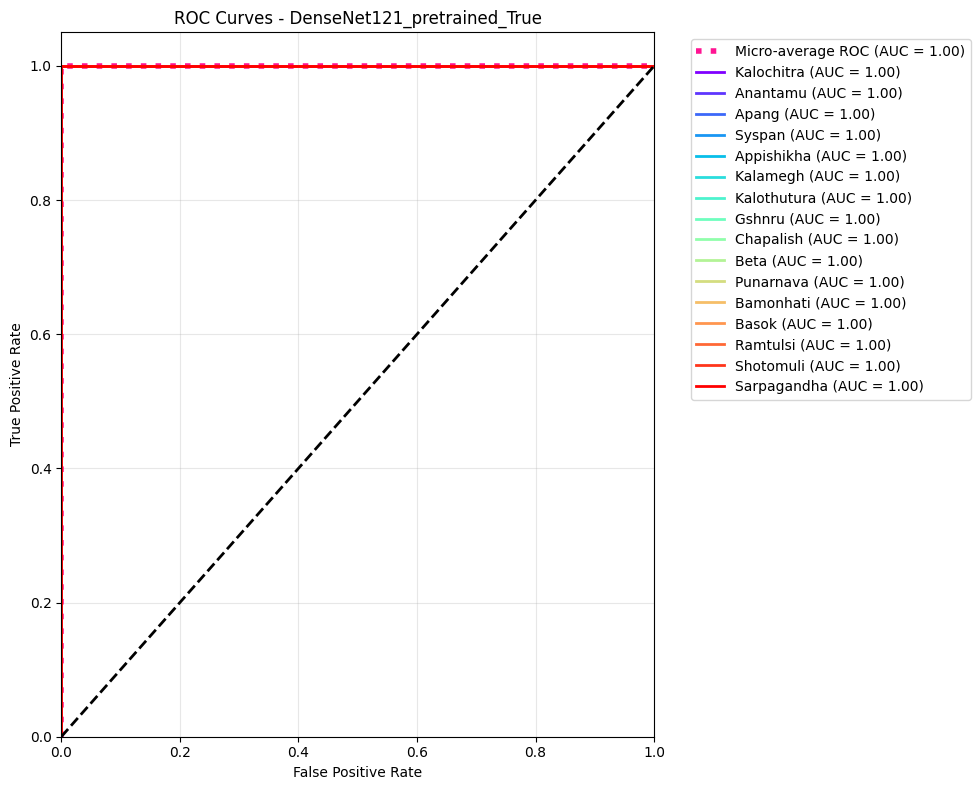

AUC Scores for DenseNet121_pretrained_True:
   Micro-average AUC: 1.0000
   Kalochitra: 1.0000
   Anantamu: 1.0000
   Apang: 1.0000
   Syspan: 1.0000
   Appishikha: 1.0000
   Kalamegh: 1.0000
   Kalothutura: 1.0000
   Gshnru: 1.0000
   Chapalish: 1.0000
   Beta: 1.0000
   Punarnava: 1.0000
   Bamonhati: 1.0000
   Basok: 1.0000
   Ramtulsi: 1.0000
   Shotomuli: 1.0000
   Sarpagandha: 1.0000
DenseNet121_pretrained_True Evaluation Complete
Testing time: 43.38 seconds

Evaluating EfficientNetB0_pretrained_True...

Evaluating EfficientNetB0_pretrained_True...
Plotting ROC curve for EfficientNetB0_pretrained_True...


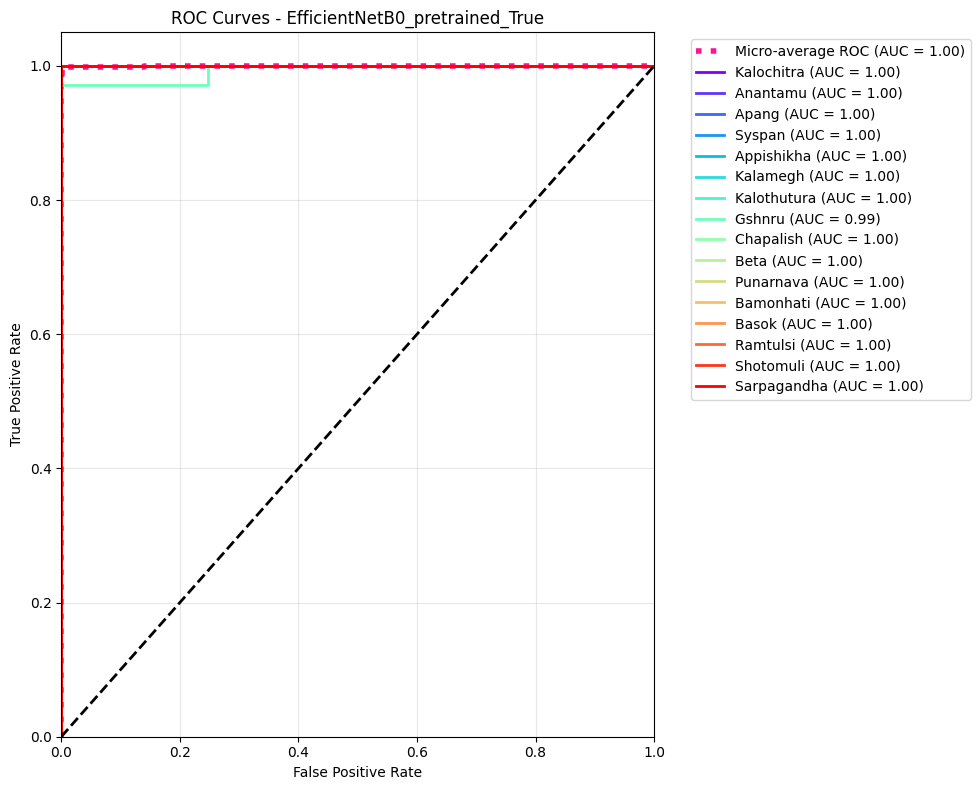

AUC Scores for EfficientNetB0_pretrained_True:
   Micro-average AUC: 0.9997
   Kalochitra: 1.0000
   Anantamu: 1.0000
   Apang: 1.0000
   Syspan: 1.0000
   Appishikha: 1.0000
   Kalamegh: 1.0000
   Kalothutura: 1.0000
   Gshnru: 0.9931
   Chapalish: 1.0000
   Beta: 1.0000
   Punarnava: 1.0000
   Bamonhati: 1.0000
   Basok: 1.0000
   Ramtulsi: 1.0000
   Shotomuli: 1.0000
   Sarpagandha: 1.0000
EfficientNetB0_pretrained_True Evaluation Complete
Testing time: 20.23 seconds

Evaluating ResNet50_pretrained_True...

Evaluating ResNet50_pretrained_True...
Plotting ROC curve for ResNet50_pretrained_True...


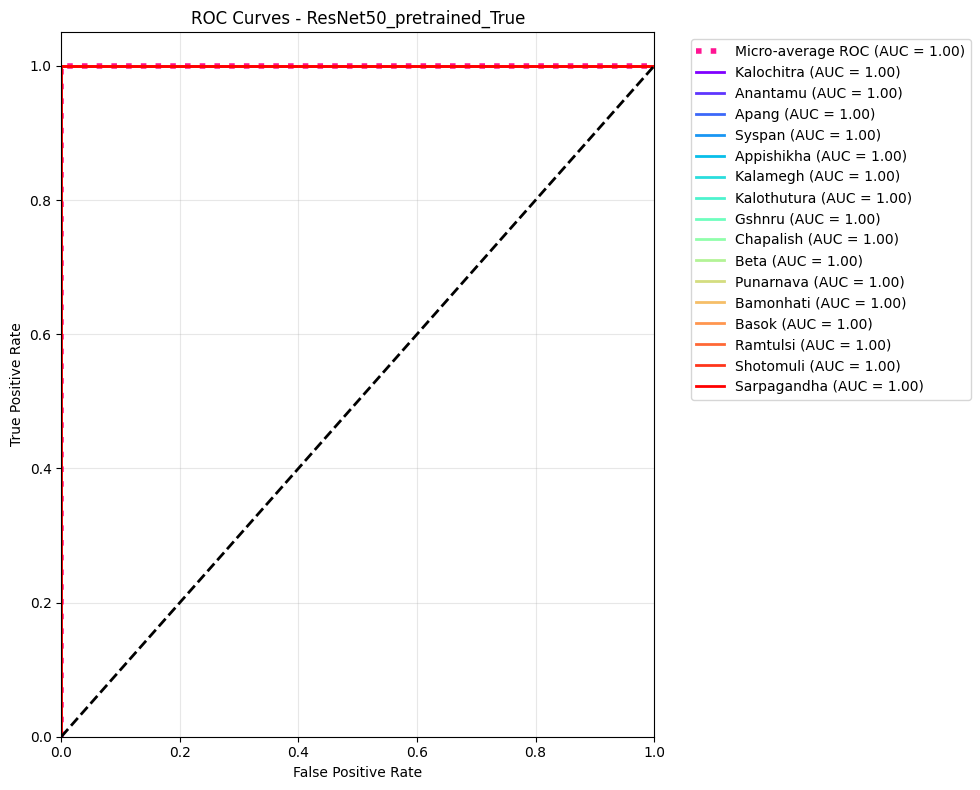

AUC Scores for ResNet50_pretrained_True:
   Micro-average AUC: 1.0000
   Kalochitra: 1.0000
   Anantamu: 1.0000
   Apang: 1.0000
   Syspan: 1.0000
   Appishikha: 1.0000
   Kalamegh: 1.0000
   Kalothutura: 1.0000
   Gshnru: 1.0000
   Chapalish: 1.0000
   Beta: 1.0000
   Punarnava: 1.0000
   Bamonhati: 1.0000
   Basok: 1.0000
   Ramtulsi: 1.0000
   Shotomuli: 1.0000
   Sarpagandha: 1.0000
ResNet50_pretrained_True Evaluation Complete
Testing time: 42.45 seconds

Evaluating DenseNet121_pretrained_False...

Evaluating DenseNet121_pretrained_False...
Plotting ROC curve for DenseNet121_pretrained_False...


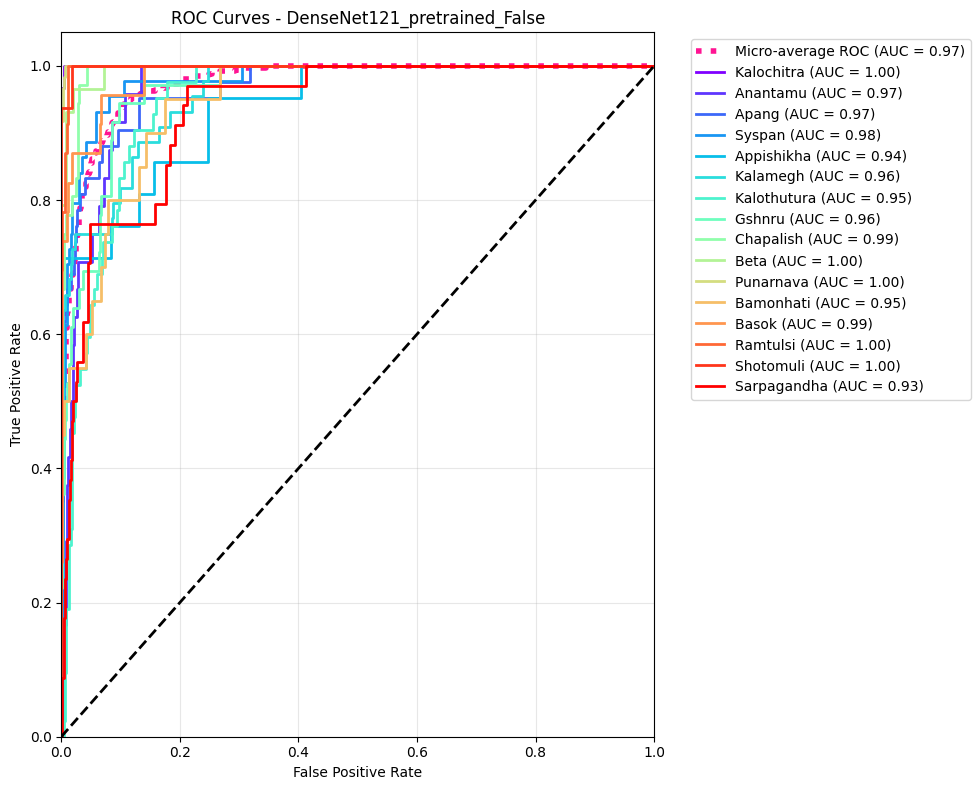

AUC Scores for DenseNet121_pretrained_False:
   Micro-average AUC: 0.9748
   Kalochitra: 0.9999
   Anantamu: 0.9668
   Apang: 0.9692
   Syspan: 0.9787
   Appishikha: 0.9394
   Kalamegh: 0.9592
   Kalothutura: 0.9476
   Gshnru: 0.9643
   Chapalish: 0.9929
   Beta: 0.9958
   Punarnava: 0.9997
   Bamonhati: 0.9477
   Basok: 0.9854
   Ramtulsi: 0.9978
   Shotomuli: 0.9989
   Sarpagandha: 0.9342
DenseNet121_pretrained_False Evaluation Complete
Testing time: 43.25 seconds

Evaluating EfficientNetB0_pretrained_False...

Evaluating EfficientNetB0_pretrained_False...
Plotting ROC curve for EfficientNetB0_pretrained_False...


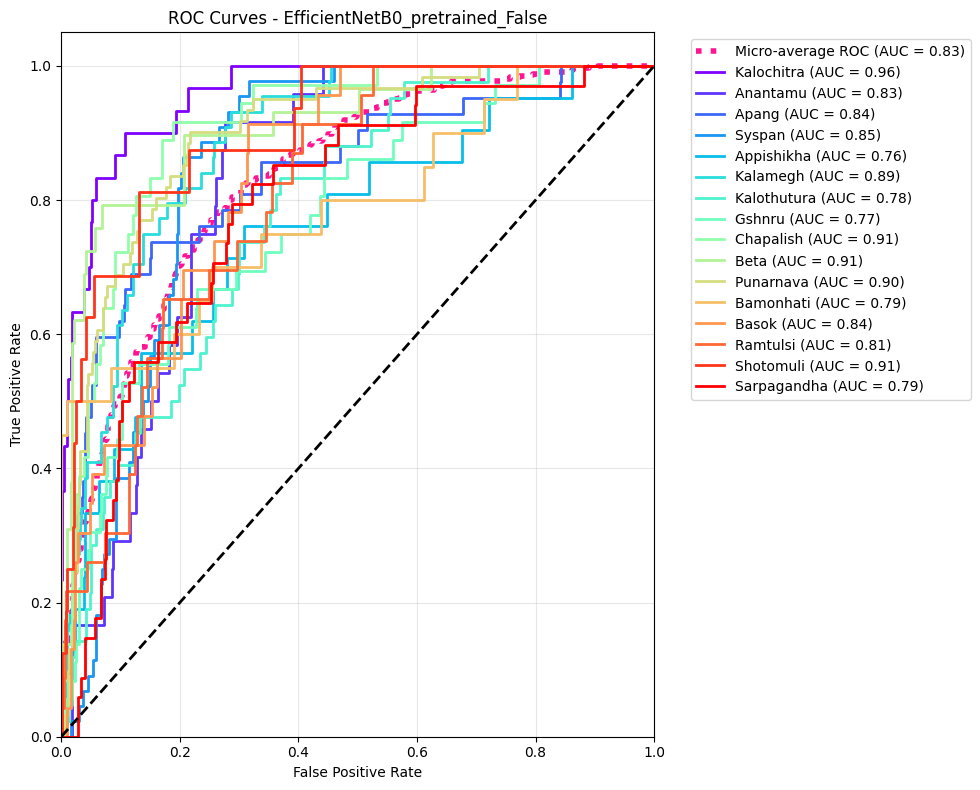

AUC Scores for EfficientNetB0_pretrained_False:
   Micro-average AUC: 0.8326
   Kalochitra: 0.9570
   Anantamu: 0.8303
   Apang: 0.8399
   Syspan: 0.8531
   Appishikha: 0.7612
   Kalamegh: 0.8871
   Kalothutura: 0.7822
   Gshnru: 0.7747
   Chapalish: 0.9118
   Beta: 0.9115
   Punarnava: 0.8976
   Bamonhati: 0.7868
   Basok: 0.8373
   Ramtulsi: 0.8124
   Shotomuli: 0.9052
   Sarpagandha: 0.7946
EfficientNetB0_pretrained_False Evaluation Complete
Testing time: 20.09 seconds

Evaluating ResNet50_pretrained_False...

Evaluating ResNet50_pretrained_False...
Plotting ROC curve for ResNet50_pretrained_False...


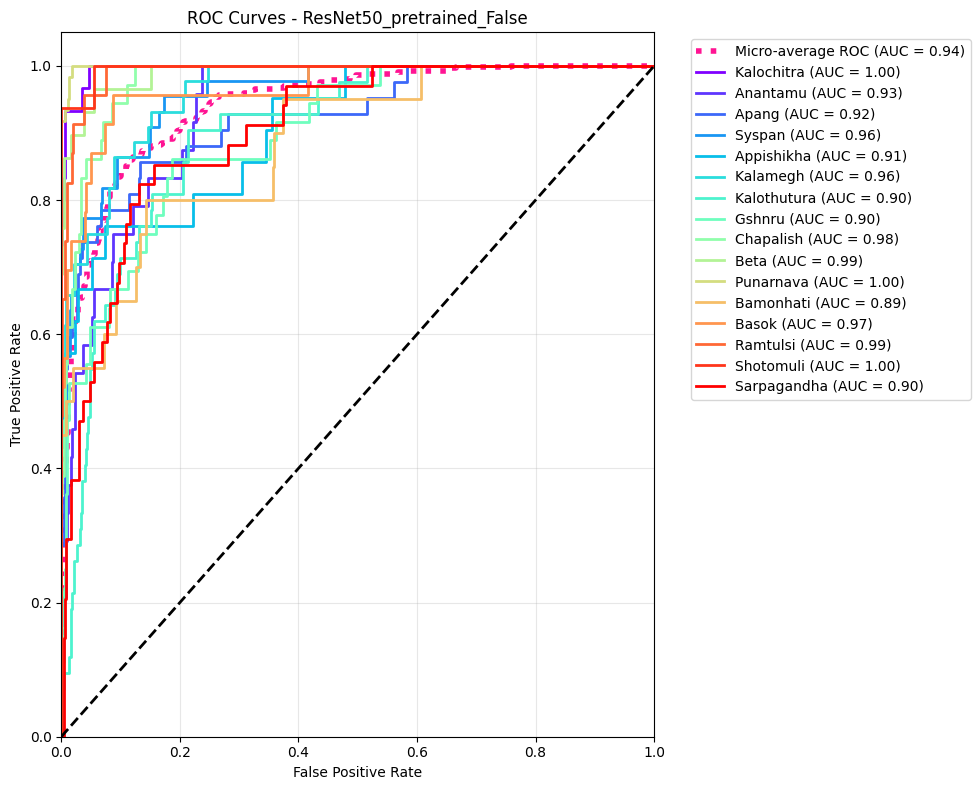

AUC Scores for ResNet50_pretrained_False:
   Micro-average AUC: 0.9414
   Kalochitra: 0.9964
   Anantamu: 0.9334
   Apang: 0.9242
   Syspan: 0.9575
   Appishikha: 0.9099
   Kalamegh: 0.9621
   Kalothutura: 0.8998
   Gshnru: 0.8999
   Chapalish: 0.9788
   Beta: 0.9905
   Punarnava: 0.9990
   Bamonhati: 0.8855
   Basok: 0.9670
   Ramtulsi: 0.9917
   Shotomuli: 0.9966
   Sarpagandha: 0.9045
ResNet50_pretrained_False Evaluation Complete
Testing time: 35.10 seconds
ALL MODELS EVALUATED SUCCESSFULLY!


In [12]:

print("COMPREHENSIVE MODEL EVALUATION")
print("=" * 50)

evaluation_results = {}

# Evaluate all model variations
for model_key in results.keys():
    model_data = results[model_key]
    model = model_data['model']
    
    # Determine which preprocessing to use based on model type
    if 'DenseNet' in model_key:
        X_test_preprocessed = X_test_densenet
    elif 'EfficientNet' in model_key:
        X_test_preprocessed = X_test_efficientnet
    elif 'ResNet' in model_key:
        X_test_preprocessed = X_test_resnet
    else:
        X_test_preprocessed = X_test_densenet  # default
    
    print(f"\nEvaluating {model_key}...")
    evaluation_results[model_key] = evaluate_model(
        model, model_key,
        X_test_preprocessed, y_test, y_test_categorical, class_names
    )

print("ALL MODELS EVALUATED SUCCESSFULLY!")

# Cell 12: Training History Visualization 

TRAINING HISTORY VISUALIZATION


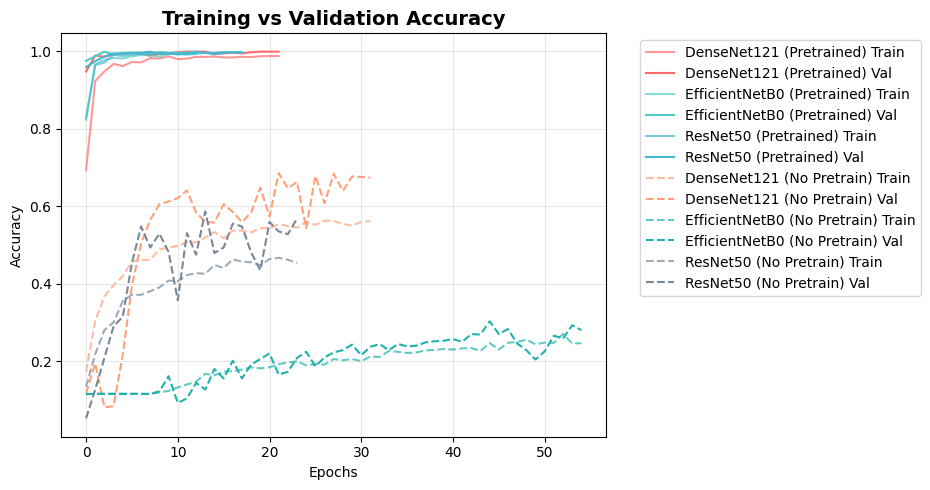

In [13]:

print("TRAINING HISTORY VISUALIZATION")
print("=" * 40)

# Plot 1: Training and Validation Accuracy
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#20B2AA', '#778899']
color_idx = 0

for model_key, model_data in results.items():
    history = model_data['history']
    color = colors[color_idx % len(colors)]
    
    if 'pretrained_True' in model_key:
        linestyle = '-'
        label_suffix = ' (Pretrained)'
    else:
        linestyle = '--'
        label_suffix = ' (No Pretrain)'
    
    model_name = model_key.replace('_pretrained_True', '').replace('_pretrained_False', '')
    
    plt.plot(history.history['accuracy'], color=color, linestyle=linestyle, 
             label=f'{model_name}{label_suffix} Train', alpha=0.7)
    plt.plot(history.history['val_accuracy'], color=color, linestyle=linestyle, 
             label=f'{model_name}{label_suffix} Val', alpha=1.0)
    
    color_idx += 1

plt.title('Training vs Validation Accuracy', fontweight='bold', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Cell 12.1: Training and Validation Loss 

TRAINING AND VALIDATION LOSS


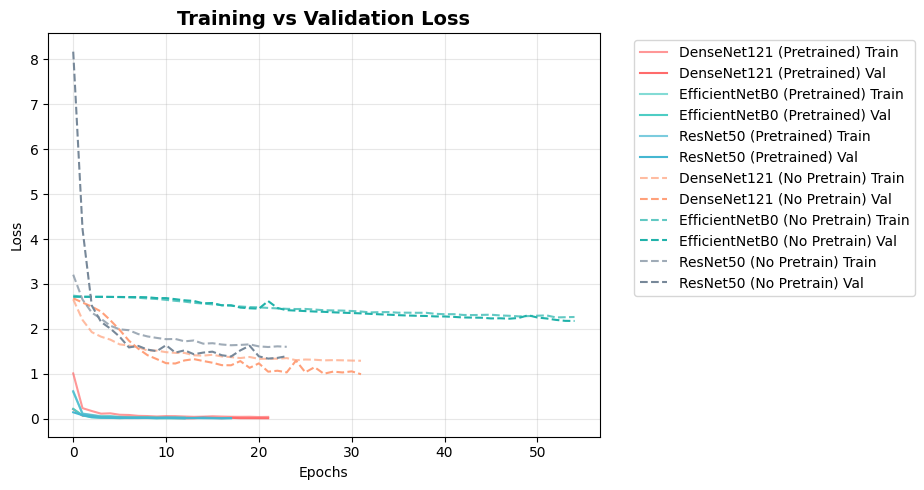

In [14]:

print("TRAINING AND VALIDATION LOSS")
print("=" * 40)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#20B2AA', '#778899']
color_idx = 0

for model_key, model_data in results.items():
    history = model_data['history']
    color = colors[color_idx % len(colors)]
    
    if 'pretrained_True' in model_key:
        linestyle = '-'
        label_suffix = ' (Pretrained)'
    else:
        linestyle = '--' 
        label_suffix = ' (No Pretrain)'
    
    model_name = model_key.replace('_pretrained_True', '').replace('_pretrained_False', '')
    
    plt.plot(history.history['loss'], color=color, linestyle=linestyle, 
             label=f'{model_name}{label_suffix} Train', alpha=0.7)
    plt.plot(history.history['val_loss'], color=color, linestyle=linestyle, 
             label=f'{model_name}{label_suffix} Val', alpha=1.0)
    
    color_idx += 1

plt.title('Training vs Validation Loss', fontweight='bold', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Cell 12.2: Model Performance Metrics Comparison 

MODEL PERFORMANCE METRICS COMPARISON


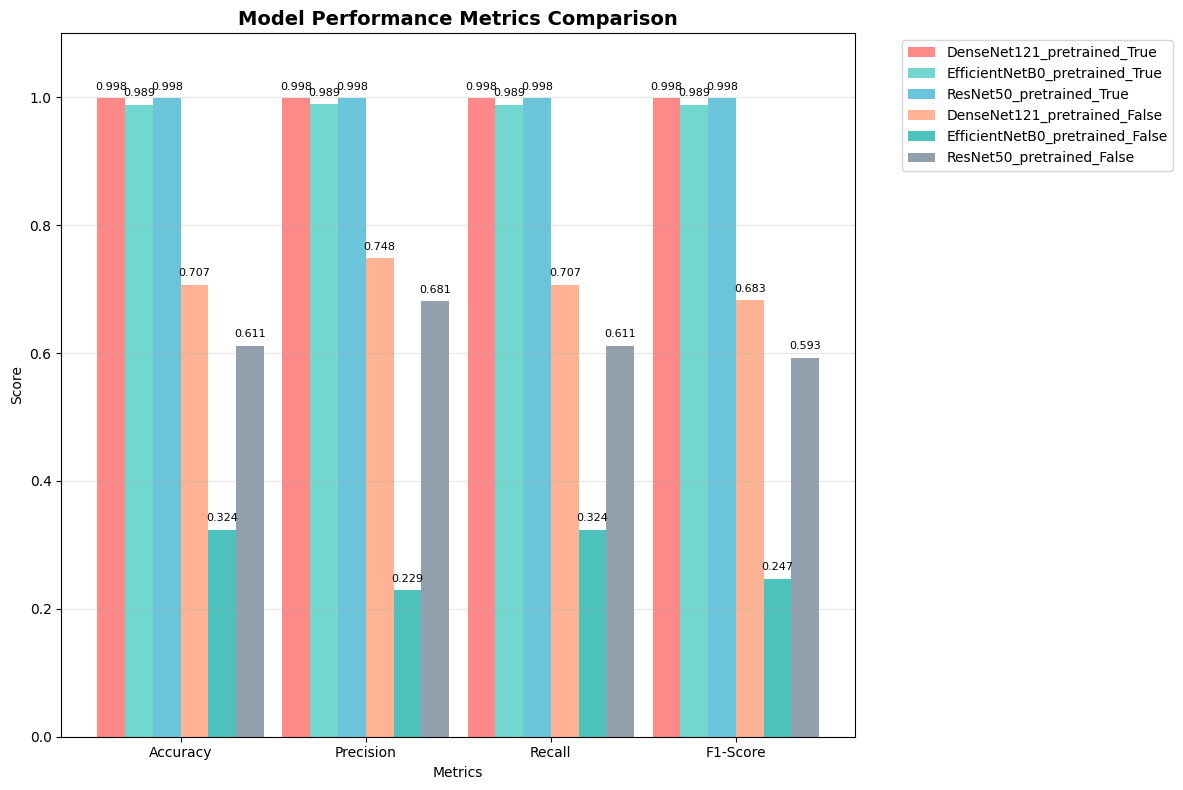

In [15]:

print("MODEL PERFORMANCE METRICS COMPARISON")
print("=" * 50)

plt.figure(figsize=(12, 8))

metrics = ['accuracy', 'precision', 'recall', 'f1_score']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Prepare data
model_names = []
metric_values = []
pretrained_status = []

for model_key in evaluation_results.keys():
    model_data = evaluation_results[model_key]
    model_metrics = []
    
    for metric in metrics:
        model_metrics.append(model_data[metric])
    
    metric_values.append(model_metrics)
    model_names.append(model_key)
    pretrained_status.append('Pretrained' if 'pretrained_True' in model_key else 'No Pretrain')

# Create grouped bar chart
x = np.arange(len(metric_names))
width = 0.15
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#20B2AA', '#778899']

for i, (model_metrics, model_name) in enumerate(zip(metric_values, model_names)):
    offset = (i - len(model_names)/2) * width + width/2
    color = colors[i % len(colors)]
    
    bars = plt.bar(x + offset, model_metrics, width, label=model_name, 
                   color=color, alpha=0.8)
    
    # Add value labels on bars
    for bar, value in zip(bars, model_metrics):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}', ha='center', va='bottom', fontsize=8)

plt.title('Model Performance Metrics Comparison', fontweight='bold', fontsize=14)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.xticks(x, metric_names)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

# Cell 12.3: Training and Testing Time Comparison 

TRAINING AND TESTING TIME COMPARISON


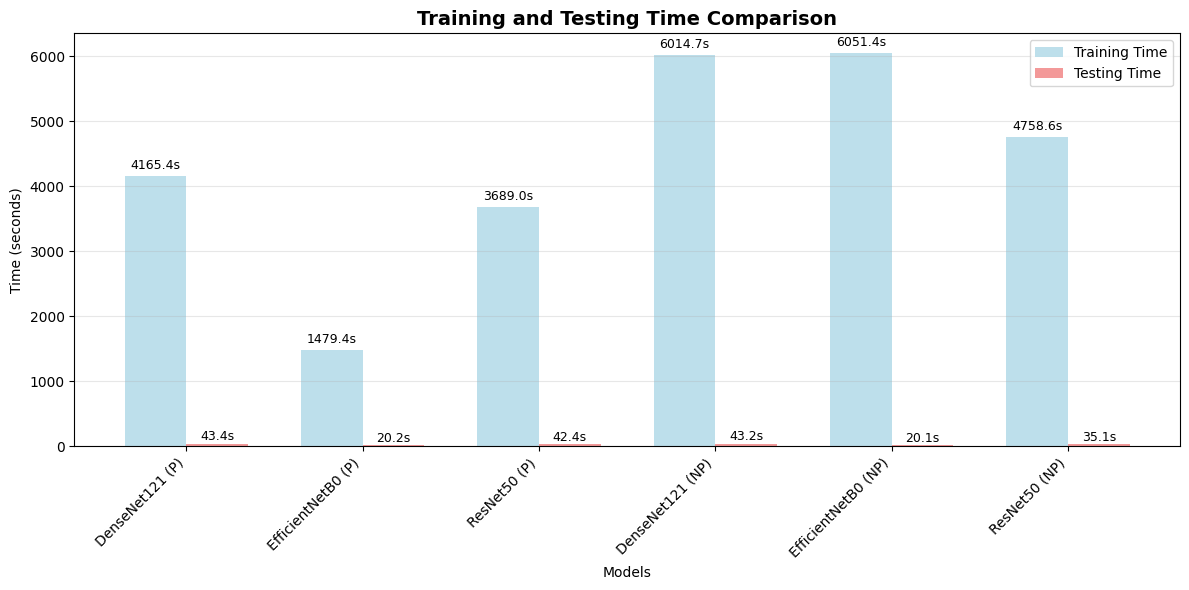

In [16]:

print("TRAINING AND TESTING TIME COMPARISON")
print("=" * 45)

plt.figure(figsize=(12, 6))

training_times = [results[model_key]['training_time'] for model_key in evaluation_results.keys()]
testing_times = [evaluation_results[model_key]['testing_time'] for model_key in evaluation_results.keys()]
model_display_names = [key.replace('_pretrained_True', ' (P)').replace('_pretrained_False', ' (NP)') 
                      for key in evaluation_results.keys()]

x = np.arange(len(model_display_names))
width = 0.35

plt.bar(x - width/2, training_times, width, label='Training Time', color='lightblue', alpha=0.8)
plt.bar(x + width/2, testing_times, width, label='Testing Time', color='lightcoral', alpha=0.8)

plt.title('Training and Testing Time Comparison', fontweight='bold', fontsize=14)
plt.xlabel('Models')
plt.ylabel('Time (seconds)')
plt.xticks(x, model_display_names, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (train_time, test_time) in enumerate(zip(training_times, testing_times)):
    plt.text(i - width/2, train_time + max(training_times)*0.01, f'{train_time:.1f}s', 
             ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, test_time + max(testing_times)*0.01, f'{test_time:.1f}s', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Cell 12.4: Class-wise Accuracy Comparison 

CLASS-WISE ACCURACY COMPARISON


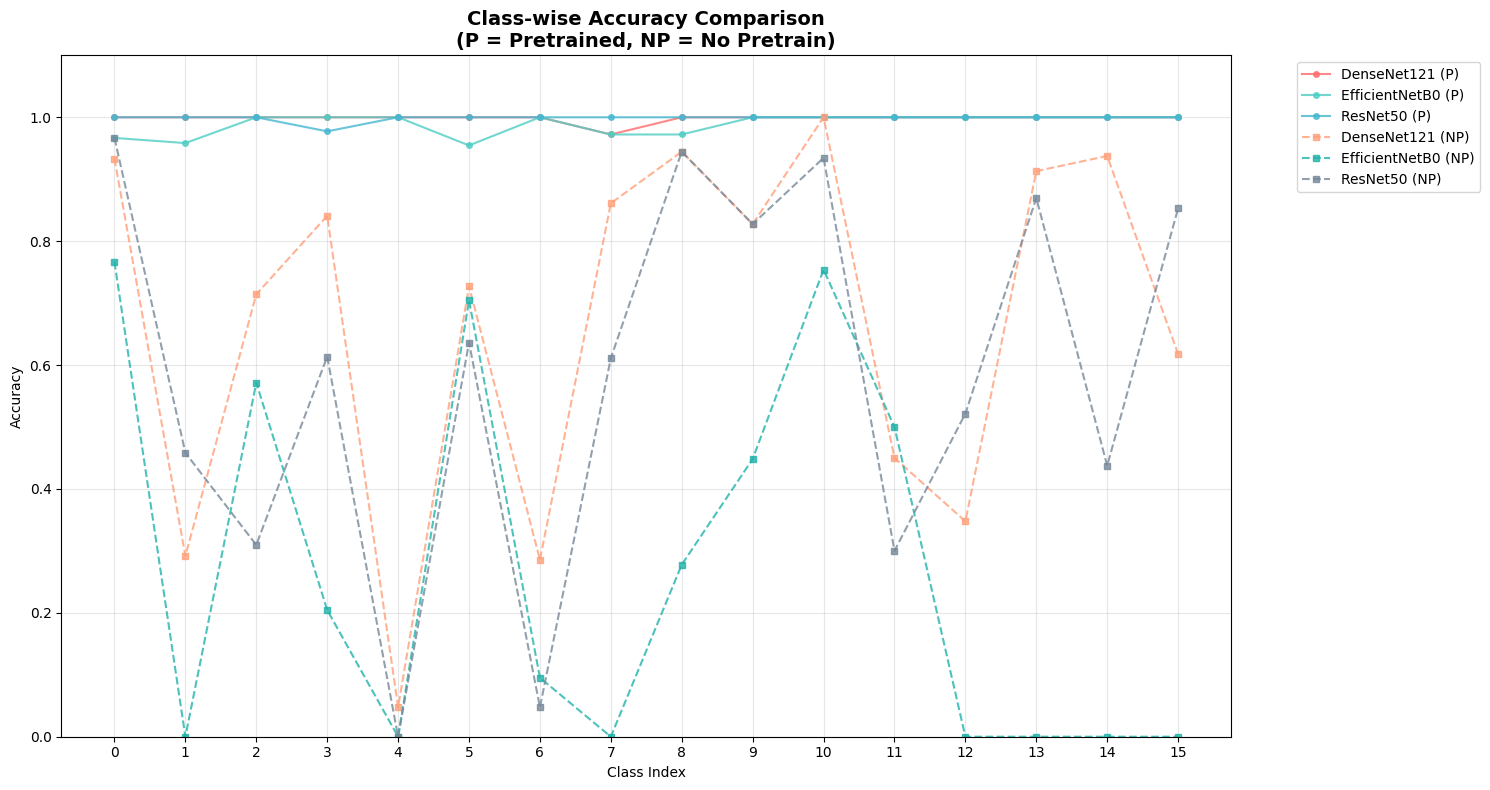

In [17]:

print("CLASS-WISE ACCURACY COMPARISON")
print("=" * 40)

plt.figure(figsize=(15, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#20B2AA', '#778899']

for i, (model_key, eval_data) in enumerate(evaluation_results.items()):
    color = colors[i % len(colors)]
    
    if 'pretrained_True' in model_key:
        linestyle = '-'
        marker = 'o'
        label_suffix = ' (P)'
    else:
        linestyle = '--'
        marker = 's'
        label_suffix = ' (NP)'
    
    model_name = model_key.replace('_pretrained_True', '').replace('_pretrained_False', '')
    
    plt.plot(range(len(class_names)), eval_data['class_accuracy'], 
             marker=marker, linestyle=linestyle, label=f'{model_name}{label_suffix}', 
             color=color, alpha=0.8, markersize=4)

plt.title('Class-wise Accuracy Comparison\n(P = Pretrained, NP = No Pretrain)', 
          fontweight='bold', fontsize=14)
plt.xlabel('Class Index')
plt.ylabel('Accuracy')
plt.xticks(range(len(class_names)), range(len(class_names)))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.ylim(0, 1.1)

# Add class names on secondary x-axis if needed
plt.tight_layout()
plt.show()

# Cell 12.5: Best Model Confusion Matrix 

BEST MODEL CONFUSION MATRIX


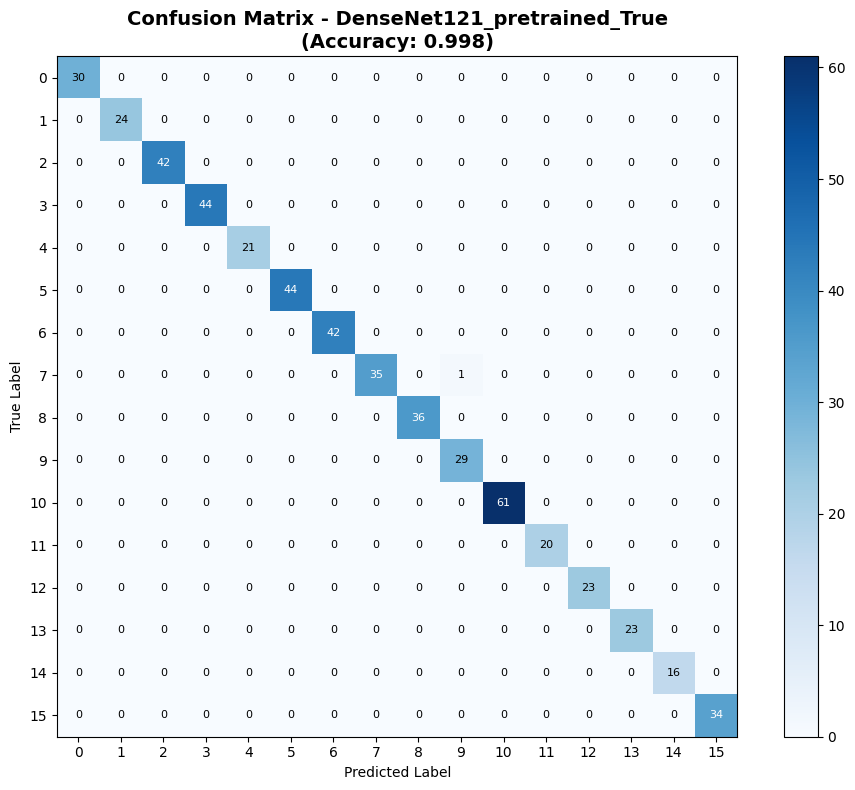

Best performing model: DenseNet121_pretrained_True with accuracy: 0.9981


In [18]:

print("BEST MODEL CONFUSION MATRIX")
print("=" * 35)

# Find best model based on accuracy
best_model_key = max(evaluation_results.keys(), 
                    key=lambda x: evaluation_results[x]['accuracy'])
best_eval = evaluation_results[best_model_key]

cm = confusion_matrix(best_eval['y_true'], best_eval['y_pred'])

plt.figure(figsize=(10, 8))
im = plt.imshow(cm, cmap='Blues', interpolation='nearest')

plt.title(f'Confusion Matrix - {best_model_key}\n(Accuracy: {best_eval["accuracy"]:.3f})', 
          fontweight='bold', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(range(len(class_names)))
plt.yticks(range(len(class_names)))

# Add text annotations
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, str(cm[i, j]), 
                ha='center', va='center', 
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=8)

plt.colorbar(im)
plt.tight_layout()
plt.show()

print(f"Best performing model: {best_model_key} with accuracy: {best_eval['accuracy']:.4f}")

# Cell 13: Statistical comparison with paired t-test

In [19]:

from scipy import stats

def perform_statistical_comparison(evaluation_results):
    """Perform paired t-test for statistical comparison"""
    
    print("STATISTICAL COMPARISON (Paired t-test)")
    print("=" * 50)
    
    model_names = list(evaluation_results.keys())
    
    # Compare each pair of models
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            model1 = model_names[i]
            model2 = model_names[j]
            
            # Get predictions
            pred1 = evaluation_results[model1]['y_pred']
            pred2 = evaluation_results[model2]['y_pred']
            true_labels = evaluation_results[model1]['y_true']
            
            # Calculate per-sample accuracy
            acc1 = (pred1 == true_labels).astype(int)
            acc2 = (pred2 == true_labels).astype(int)
            
            # Perform paired t-test
            t_stat, p_value = stats.ttest_rel(acc1, acc2)
            
            print(f"\n{model1} vs {model2}:")
            print(f"  T-statistic: {t_stat:.4f}")
            print(f"  P-value: {p_value:.4f}")
            
            if p_value < 0.05:
                if np.mean(acc1) > np.mean(acc2):
                    print(f"  {model1} performs SIGNIFICANTLY better than {model2}")
                else:
                    print(f"  {model2} performs SIGNIFICANTLY better than {model1}")
            else:
                print(f"  No significant difference between {model1} and {model2}")

perform_statistical_comparison(evaluation_results)

STATISTICAL COMPARISON (Paired t-test)

DenseNet121_pretrained_True vs EfficientNetB0_pretrained_True:
  T-statistic: 2.2447
  P-value: 0.0252
  DenseNet121_pretrained_True performs SIGNIFICANTLY better than EfficientNetB0_pretrained_True

DenseNet121_pretrained_True vs ResNet50_pretrained_True:
  T-statistic: 0.0000
  P-value: 1.0000
  No significant difference between DenseNet121_pretrained_True and ResNet50_pretrained_True

DenseNet121_pretrained_True vs DenseNet121_pretrained_False:
  T-statistic: 14.5469
  P-value: 0.0000
  DenseNet121_pretrained_True performs SIGNIFICANTLY better than DenseNet121_pretrained_False

DenseNet121_pretrained_True vs EfficientNetB0_pretrained_False:
  T-statistic: 32.9359
  P-value: 0.0000
  DenseNet121_pretrained_True performs SIGNIFICANTLY better than EfficientNetB0_pretrained_False

DenseNet121_pretrained_True vs ResNet50_pretrained_False:
  T-statistic: 18.0312
  P-value: 0.0000
  DenseNet121_pretrained_True performs SIGNIFICANTLY better than ResNe

# Cell 14: Create comprehensive results table

In [20]:

def create_results_table(evaluation_results, results):
    """Create final comparison table for all models"""
    
    if len(evaluation_results) == 0:
        print("evaluation_results is EMPTY — nothing to summarize.")
        return None

    if len(results) == 0:
        print("results dictionary is EMPTY — training data missing.")
        return None
    
    table_data = []
    
    for model_key in evaluation_results.keys():
        print(f"Processing model: {model_key} ...")

        eval_data = evaluation_results[model_key]
        training_data = results[model_key]

        # Extract best validation accuracy
        history = training_data["history"]
        if "val_accuracy" in history.history:
            best_val_acc = max(history.history["val_accuracy"])
        else:
            best_val_acc = 0.0

        # Get pretrained status
        pretrained_status = "Yes" if training_data.get('pretrained', True) else "No"

        row = {
            "Model": model_key,
            "Pretrained": pretrained_status,
            "Accuracy": f"{eval_data['accuracy']:.4f}",
            "Precision": f"{eval_data['precision']:.4f}",
            "Recall": f"{eval_data['recall']:.4f}",
            "F1-Score": f"{eval_data['f1_score']:.4f}",
            "AUC (Micro)": f"{eval_data['auc_scores']['micro']:.4f}",
            "Training Time (s)": f"{training_data['training_time']:.2f}",
            "Testing Time (s)": f"{eval_data['testing_time']:.2f}",
            "Best Val Accuracy": f"{best_val_acc:.4f}"
        }

        table_data.append(row)

    df_results = pd.DataFrame(table_data)

    print("\nFINAL RESULTS SUMMARY")
    print("=" * 100)
    print(df_results.to_string(index=False))

    return df_results

final_results_table = create_results_table(evaluation_results, results)

Processing model: DenseNet121_pretrained_True ...
Processing model: EfficientNetB0_pretrained_True ...
Processing model: ResNet50_pretrained_True ...
Processing model: DenseNet121_pretrained_False ...
Processing model: EfficientNetB0_pretrained_False ...
Processing model: ResNet50_pretrained_False ...

FINAL RESULTS SUMMARY
                          Model Pretrained Accuracy Precision Recall F1-Score AUC (Micro) Training Time (s) Testing Time (s) Best Val Accuracy
    DenseNet121_pretrained_True        Yes   0.9981    0.9982 0.9981   0.9981      1.0000           4165.41            43.38            0.9986
 EfficientNetB0_pretrained_True        Yes   0.9886    0.9890 0.9886   0.9886      0.9997           1479.44            20.23            0.9986
       ResNet50_pretrained_True        Yes   0.9981    0.9981 0.9981   0.9981      1.0000           3688.98            42.45            0.9986
   DenseNet121_pretrained_False         No   0.7067    0.7485 0.7067   0.6831      0.9748           60

# Cell 15: Save models and results

In [21]:

print("Saving models and results...")

# Save all models
for model_key, model_data in results.items():
    model = model_data['model']
    safe_filename = model_key.replace(' ', '_').replace('/', '_')
    model.save(f'{safe_filename}_final_model.h5')
    print(f"Saved: {safe_filename}_final_model.h5")

# Save results to CSV
if final_results_table is not None:
    final_results_table.to_csv('task2_model_comparison_results.csv', index=False)
    print("Results table saved to CSV")

# Save evaluation results
import pickle
with open('task2_evaluation_results.pkl', 'wb') as f:
    pickle.dump(evaluation_results, f)
print("Evaluation results pickled")

print("All models and results saved successfully!")

Saving models and results...
Saved: DenseNet121_pretrained_True_final_model.h5
Saved: EfficientNetB0_pretrained_True_final_model.h5
Saved: ResNet50_pretrained_True_final_model.h5
Saved: DenseNet121_pretrained_False_final_model.h5
Saved: EfficientNetB0_pretrained_False_final_model.h5
Saved: ResNet50_pretrained_False_final_model.h5
Results table saved to CSV
Evaluation results pickled
All models and results saved successfully!
